In [1]:
using Pkg
Pkg.activate("C:/Users/av589/Desktop/Julia/ants")
using BifurcationKit
using Plots
using DifferentialEquations
using LaTeXStrings
using JLD2

  Activating project at `C:\Users\av589\Desktop\Julia\ants`


In [2]:
function model_3d(x,p)
    (alphaC,alphaB,alphaT,beta,omegaC,omegaB,k,n)=p
    S,C,T = x
    B = 1 - S - C - T
    Sdot = -(alphaC+alphaB+alphaT)*S + beta*T + (omegaC*C+omegaB*B)/(1+ (C/k)^n)
    Cdot = alphaC*S - omegaC*C/(1+ (C/k)^n)
    Tdot = alphaT*S - beta*T
    [
        Sdot
        Cdot
        Tdot
    ]
end

function model_6d(x,p)
    (alphaC,alphaB,alphaT,beta,omegaC,omegaB,k,n,u,aC,aB,aT,aBC,aTC,bC,aCB,aTB,bB,aCT,aBT,bT)=p
    #print("bug")
    S,C,T,xC,xB,xT = x
    B = 1 - S - C - T
    Sdot = -(alphaC*(1+xC)+alphaB*(1+xB)+alphaT*(1+xT))*S + beta*T + (omegaC*C+omegaB*B)/(1 + (C/k)^n)
    Cdot = alphaC*(1+xC)*S - omegaC*C/(1 + (C/k)^n)
    Tdot = alphaT*(1+xT)*S - beta*T
    xCdot = -xC + tanh(u*(aC*xC + aBC*xB + aTC*xT + bC*C*xC))
    xBdot = -xB + tanh(u*(aB*xB + aCB*xC + aTB*xT + bB*C*xB))
    xTdot = -xT + tanh(u*(aT*xT + aCT*xC + aBT*xB + bT*C*xT))
    [
        Sdot
        Cdot
        Tdot
        xCdot
        xBdot
        xTdot
    ]
end

model_6d (generic function with 1 method)

In [3]:
par = (alphaC=1.0,alphaB=1.0,alphaT=1.0,beta=0.6,omegaC=0.6,omegaB=0.5,k=0.5,n=4,u=0.6,aC=1.0,aB=1.0,aT=1.0,aBC=-0.2,aTC=-0.2,bC=-0.5,aCB=-0.2,aTB=0.5,bB=-0.5,aCT=-0.2,aBT=0.5,bT=0.5)
alphaC,alphaB,alphaT,beta,omegaC,omegaB,k,n,u,aC,aB,aT,aBC,aTC,bC,aCB,aTB,bB,aCT,aBT,bT = par
u0 = [1.0,0,0,0.1,0.1,0.1]
tspan=(0.0,30.0)

opts_br = ContinuationPar(
    p_min = 0.0, p_max = 1.0,
    ds = 1e-4,
    dsmax = 5e-4,
    dsmin = 1e-6,

    newton_options = NewtonPar(
        tol = 1e-10,   # <-- much tighter
        max_iterations = 100,
        verbose = true
    ),
    tol_stability = 1e-8,  # <-- prevents spurious “BP” classification
)
u_bif_problem = BifurcationProblem(model_6d, u0, par, (@optic _.u),record_from_solution = (x, p; k...) -> (S = x[1], C = x[2], T = x[3], xC = x[4], xB = x[5], xT = x[6]))
#u_branch_equilibria = continuation(u_bif_problem, PALC(),opts_br)

┌─ Bifurcation Problem with uType Vector{Float64}
├─ Inplace:  false
├─ Symmetric: false
└─ Parameter: u

In [4]:
opts_br = ContinuationPar(
    p_min = 0.0, p_max = 1.0,
    ds = 1e-5,
    dsmax = 5e-3,
    dsmin = 1e-6,
    detect_bifurcation = 3,
    n_inversion = 8,

    newton_options = NewtonPar(
        tol = 1e-12,
        max_iterations = 100,
        verbose = false
    ),
    tol_stability = 1e-12,
)

# automatic bifurcation diagram computation
diagram = bifurcationdiagram(u_bif_problem,MoorePenrose(),
	2,
	opts_br,bothside = true
	)

[Bifurcation diagram]
 ┌─ From 0-th bifurcation point.
 ├─ Children number: 2
 └─ Root (recursion level 1)
      ┌─ Curve type: EquilibriumCont
      ├─ Number of points: 172
      ├─ Type of vectors: Vector{Float64}
      ├─ Parameter u starts at 0.0, ends at 1.0
      ├─ Algo: MoorePenrose
      └─ Special points:

- #  1, endpoint at u ≈ +0.00000000,                                                                     step =   0
- #  2,       bp at u ≈ +0.61650665 ∈ (+0.61650643, +0.61650665), |δp|=2e-07, [converged], δ = ( 1,  0), step = 116
- #  3, endpoint at u ≈ +1.00000000,                                                                     step = 171


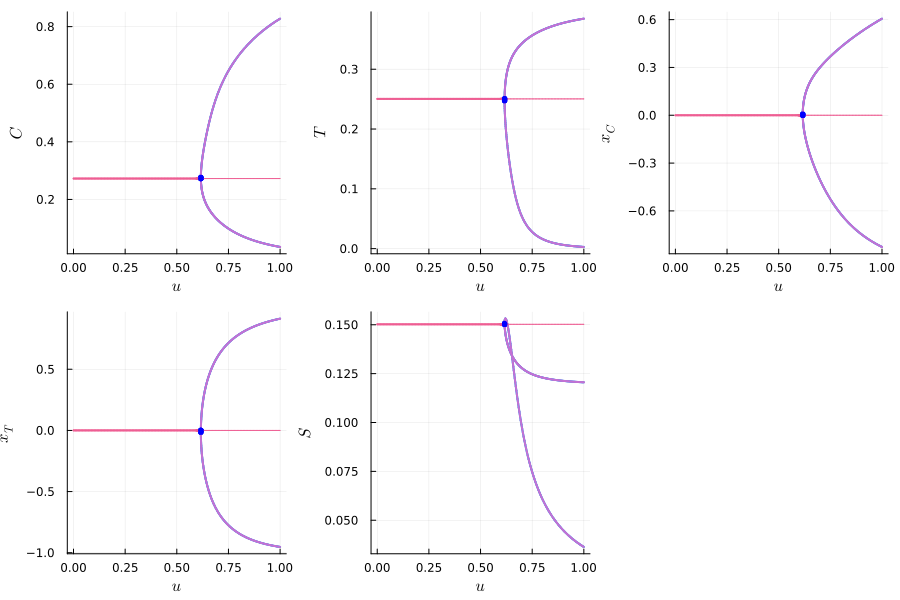

In [5]:
p1 = plot(diagram,vars = (:param,:C),ylabel = L"C",label ="",xlabel = L"u")#,ylims = (0.1,0.2),xlims = (0.5,0.7))
p2 = plot(diagram,vars = (:param,:T),ylabel = L"T",label = "",xlabel = L"u")
p3 = plot(diagram,vars = (:param,:xC),ylabel =L"x_C",label = "",xlabel = L"u")
p4 = plot(diagram,vars = (:param,:xT),ylabel = L"x_T",label = "",xlabel = L"u")
p5 = plot(diagram,vars = (:param,:S),ylabel = L"S",label = "",xlabel = L"u")

plot(p1,p2,p3,p4,p5, layout = 6,size = (900,600))

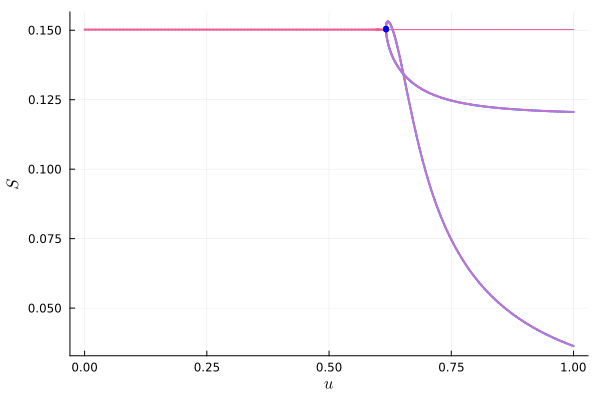

In [188]:
plot(p5)

In [ ]:
plot(size = (800,500),plot(alpha_br_eq,vars = (:param,:A),ylims = (-0.05,1.05)),plot(alpha_br_eq,vars = (:param,:S),ylims = (-0.05,1.05)),plot(alpha_br_eq,vars = (:param,:R),ylims = (-0.05,1.05)))

In [ ]:
par3d = (gamma0=0.01, beta = 0.05, xi = 0.1,eta = 0.01, alpha = 0.1, N=1,M=1,kappa0 = 0.0002,kappa1=0.0001)
u0 = [0.6,0.1,0.8]

alpha_bif_problem = BifurcationProblem(AntODEs_ASR, u0,par3d,(@optic _.alpha),record_from_solution = (x, p; k...) -> (A = x[1], S = x[2], R = x[3]))
alpha_br_eq = continuation(alpha_bif_problem, PALC(), ContinuationPar(p_min = 0.001,p_max = 0.30,dsmax = 0.001,ds=0.0001,dsmin = 0.00001), bothside = true)

In [76]:
using LinearAlgebra, ForwardDiff, Arpack

# function to compute Jacobian at x,p
function J_at(x,p)
    f = y -> model_6d(y, p)           # closure capturing p
    ForwardDiff.jacobian(f, x)
end

# compute smallest magnitude eigenvalue (abs) of J at (x,p)
function min_abs_eig(x,p)
    J = J_at(x,p)
    # use Arpack to get smallest magnitude eigenvalue
    vals, vecs = eigs(J; nev=1, which=:SM, tol=1e-8, maxiter=200)
    return abs(real(vals[1])), vals[1], vecs[:,1]
end

# sample branch points near the suspicious parameter region
# suppose you have the branch points in `branch` with fields .x and .param
ps = Float64[]  # parameters
mins = Float64[]  # min abs eigenvalue
eigvals = ComplexF64[]
for pt in branch  # adapt name: branch = diagram[1] or diagram.branches[1]
    x = pt.u          # or pt.x depending on your branch object
    p = pt.param      # adapt to your branch data structure
    push!(ps, p)
    m, λ, _ = min_abs_eig(x, p)
    push!(mins, m)
    push!(eigvals, λ)
end

# quick check: print parameter values where min abs eig < threshold
for (p,m) in zip(ps, mins)
    if m < 1e-5
        println("near-singular at p=$(p): |λ_min|=$(m)")
    end
end


ArgumentError: ArgumentError: Package ForwardDiff not found in current path.
- Run `import Pkg; Pkg.add("ForwardDiff")` to install the ForwardDiff package.